# Seeds Dataset - Unsupervised Learning (Clustering)

**Dataset:** Seeds Dataset  
**Task:** Cluster seeds based on measurements like area, perimeter, etc.  
**Algorithms:** K-Means Clustering & Agglomerative Hierarchical Clustering

---
##  Phase 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

print('All libraries imported successfully!')

All libraries imported successfully!


---
##  Phase 1: Load the Dataset

In [ ]:
# Column names based on the Seeds dataset description
column_names = [
    'Area',
    'Perimeter',
    'Compactness',
    'Kernel_Length',
    'Kernel_Width',
    'Asymmetry_Coefficient',
    'Kernel_Groove_Length',
    'Class'  # 1=Kama, 2=Rosa, 3=Canadian
]

# Load from URL (UCI Repository)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'
df = pd.read_csv(url, sep='\t+', names=column_names, engine='python')

print(' Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head(10)

 Dataset loaded successfully!
Shape: (210, 8)


,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coefficient,Kernel_Groove_Length,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1
6,14.69,14.49,0.8799,5.563,3.259,3.586,5.219,1
7,14.11,14.10,0.8911,5.420,3.302,2.700,5.000,1
8,16.63,15.46,0.8747,6.053,3.465,2.040,5.877,1
9,16.44,15.25,0.8880,5.884,3.505,1.969,5.533,1


---
## Phase 1: Exploratory Data Analysis (EDA)

In [ ]:
# Basic info
print('      Dataset Info ')
df.info()


      Dataset Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Area                   210 non-null    float64
 1   Perimeter              210 non-null    float64
 2   Compactness            210 non-null    float64
 3   Kernel_Length          210 non-null    float64
 4   Kernel_Width           210 non-null    float64
 5   Asymmetry_Coefficient  210 non-null    float64
 6   Kernel_Groove_Length   210 non-null    float64
 7   Class                  210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [ ]:
# Class distribution
print(' Class Distribution ')
class_map = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}
print(df['Class'].map(class_map).value_counts())

# Check for missing values
print('\n Missing Values ')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

 Class Distribution 
Class
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64

 Missing Values 
Area                     0
Perimeter                0
Compactness              0
Kernel_Length            0
Kernel_Width             0
Asymmetry_Coefficient    0
Kernel_Groove_Length     0
Class                    0
dtype: int64

Total missing values: 0


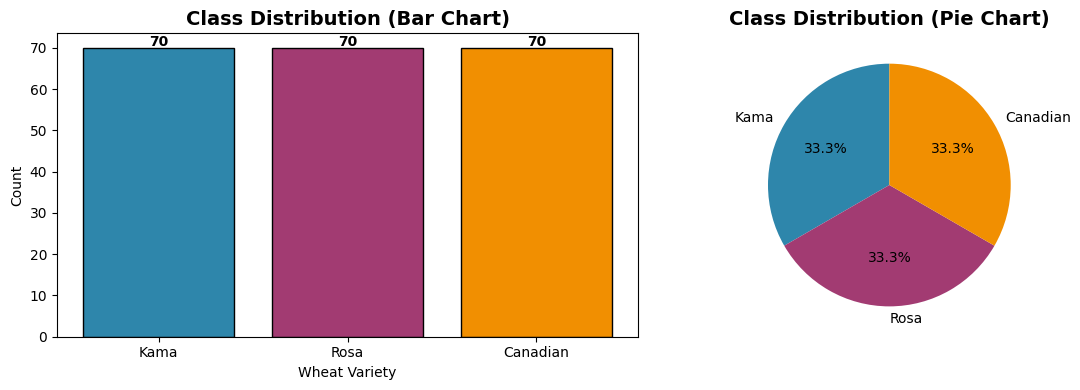

 Balanced dataset - 70 samples per class


In [ ]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['Class'].map(class_map).value_counts()
axes[0].bar(counts.index, counts.values, color=['#2E86AB', '#A23B72', '#F18F01'], edgecolor='black')
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Wheat Variety')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2E86AB', '#A23B72', '#F18F01'], startangle=90)
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Balanced dataset - 70 samples per class')

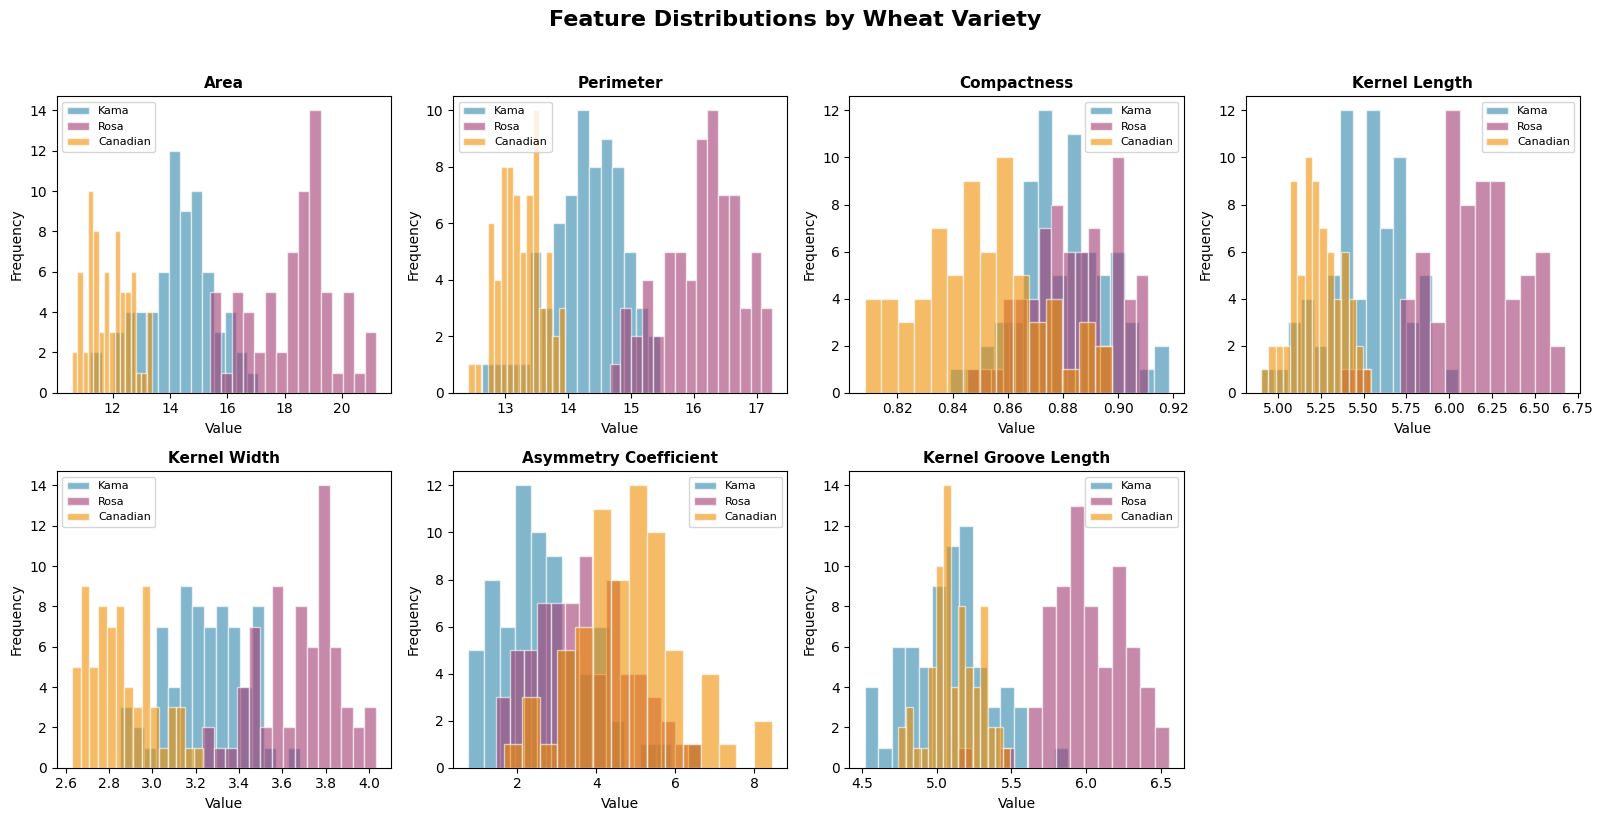

In [ ]:
# Feature distributions
features = column_names[:-1]  # Exclude class

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
colors = ['#2E86AB', '#A23B72', '#F18F01']

for i, feature in enumerate(features):
    for j, (cls, label) in enumerate(class_map.items()):
        axes[i].hist(df[df['Class'] == cls][feature], alpha=0.6,
                     label=label, color=colors[j], bins=15, edgecolor='white')
    axes[i].set_title(feature.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Feature Distributions by Wheat Variety', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

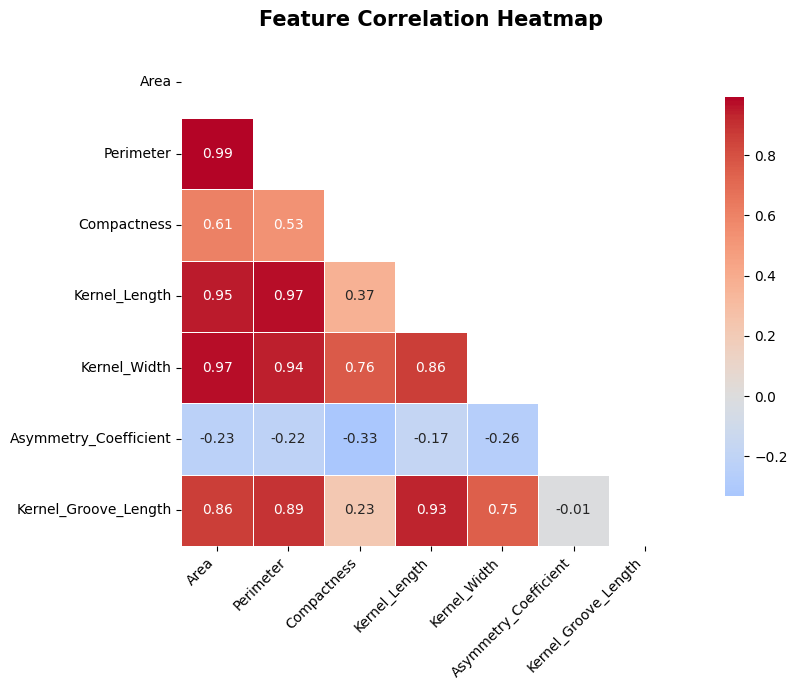


 Insight: Area, Perimeter, and Kernel Length are highly correlated (>0.9)


In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr_matrix = df[features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Insight: Area, Perimeter, and Kernel Length are highly correlated (>0.9)')

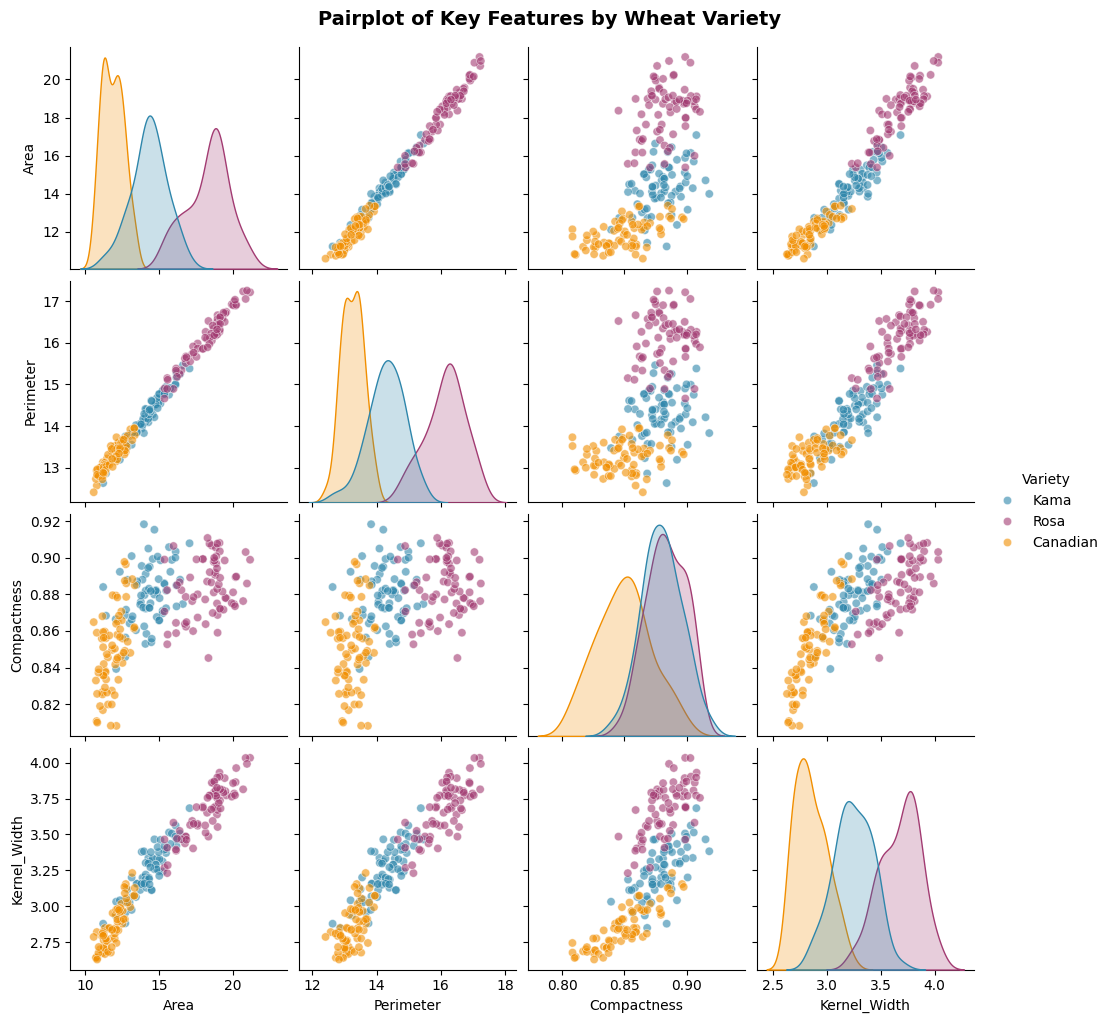

In [ ]:
# Pairplot for key features
df_plot = df.copy()
df_plot['Variety'] = df_plot['Class'].map(class_map)

key_features = ['Area', 'Perimeter', 'Compactness', 'Kernel_Width', 'Variety']
g = sns.pairplot(df_plot[key_features], hue='Variety',
                 palette={'Kama': '#2E86AB', 'Rosa': '#A23B72', 'Canadian': '#F18F01'},
                 diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot of Key Features by Wheat Variety', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

---
##  Phase 1: Data Cleaning & Preprocessing

In [ ]:
# Separate features from labels (labels only for evaluation, NOT for clustering)
X = df[features].copy()
y_true = df['Class'].values  # Ground truth for evaluation only

print('Features shape:', X.shape)
print('\n--- Checking for Outliers using IQR ---')

for feat in features:
    Q1 = X[feat].quantile(0.25)
    Q3 = X[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = X[(X[feat] < lower) | (X[feat] > upper)].shape[0]
    print(f'{feat}: {outliers} outlier(s) [Range: {lower:.3f} - {upper:.3f}]')

print('\n Very few outliers — dataset is clean and well-structured')
print(' No missing values found')
print('No duplicate rows:', df.duplicated().sum())

Features shape: (210, 7)

--- Checking for Outliers using IQR ---
Area: 0 outlier(s) [Range: 4.717 - 24.858]
Perimeter: 0 outlier(s) [Range: 10.052 - 19.113]
Compactness: 3 outlier(s) [Range: 0.811 - 0.934]
Kernel_Length: 0 outlier(s) [Range: 4.186 - 7.056]
Kernel_Width: 0 outlier(s) [Range: 2.017 - 4.488]
Asymmetry_Coefficient: 2 outlier(s) [Range: -0.749 - 8.080]
Kernel_Groove_Length: 0 outlier(s) [Range: 3.797 - 7.125]

 Very few outliers — dataset is clean and well-structured
 No missing values found
No duplicate rows: 0


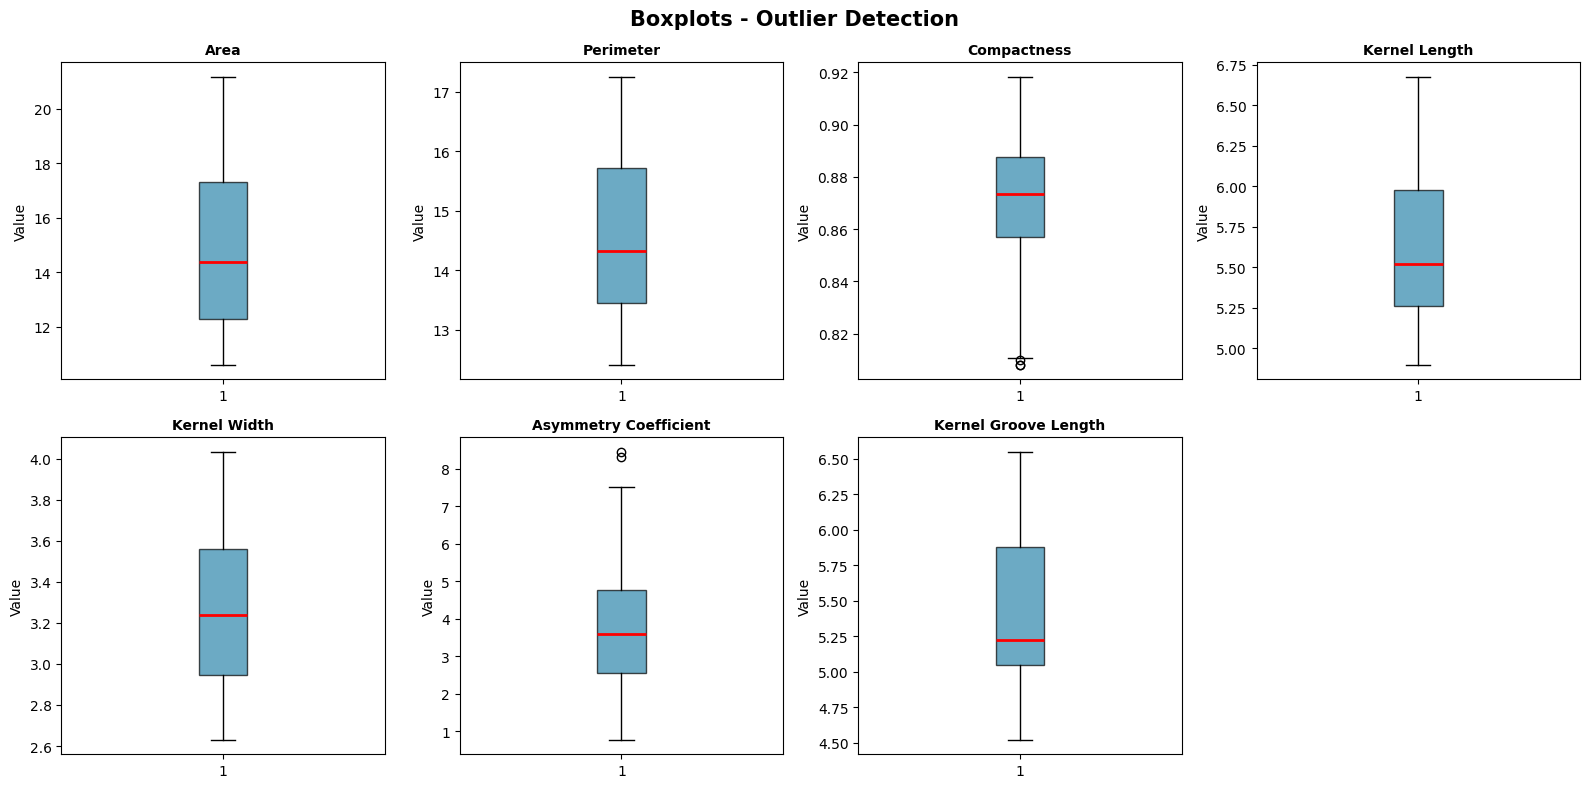

In [ ]:
# Boxplot to visualize outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].boxplot(X[feat], patch_artist=True,
                    boxprops=dict(facecolor='#2E86AB', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat.replace('_', ' '), fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')

axes[-1].set_visible(False)
plt.suptitle('Boxplots - Outlier Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Phase 2: Algorithm 1 — K-Means Clustering

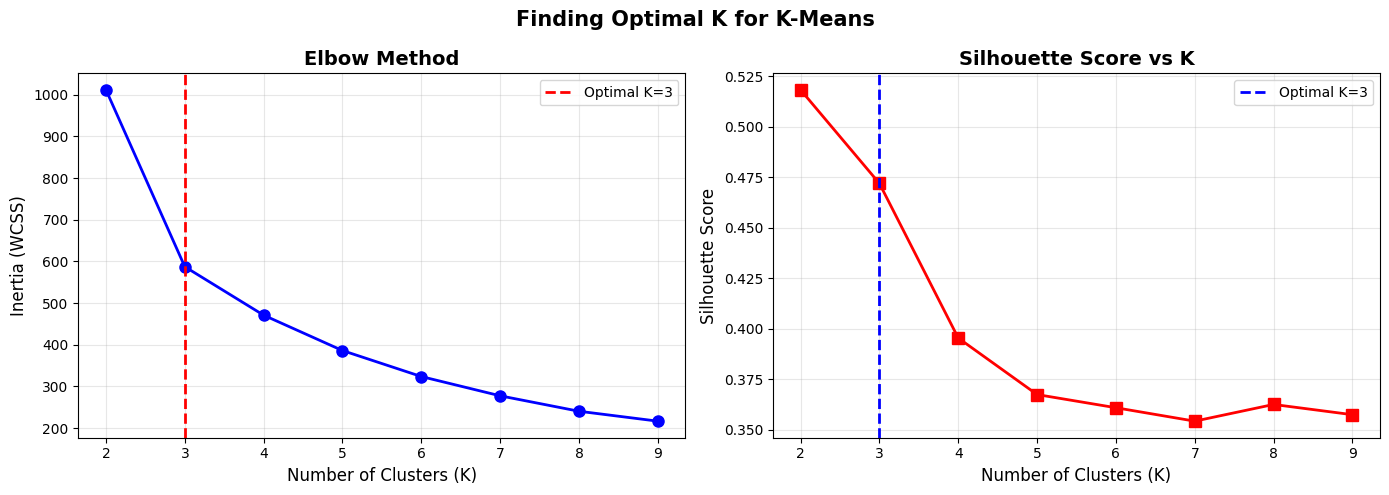

Best Silhouette Score at K=3: 0.4719
 Both Elbow and Silhouette confirm K=3 (matches the 3 wheat varieties!)


In [ ]:
# Finding optimal K using Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=2, label='Optimal K=3')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='blue', linestyle='--', linewidth=2, label='Optimal K=3')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Finding Optimal K for K-Means', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best Silhouette Score at K=3: {silhouette_scores[1]:.4f}')
print(' Both Elbow and Silhouette confirm K=3 (matches the 3 wheat varieties!)')

In [ ]:
# Train K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
kmeans_labels = kmeans.fit_predict(X)

# Evaluation metrics
km_silhouette = silhouette_score(X, kmeans_labels)
km_db = davies_bouldin_score(X, kmeans_labels)
km_ch = calinski_harabasz_score(X, kmeans_labels)
km_ari = adjusted_rand_score(y_true, kmeans_labels)

print('      K-Means (K=3) Results      ')
print(f'Silhouette Score:          {km_silhouette:.4f}  (closer to 1 = better)')
print(f'Davies-Bouldin Index:      {km_db:.4f}  (closer to 0 = better)')
print(f'Calinski-Harabasz Score:   {km_ch:.2f} (higher = better)')
print(f'Adjusted Rand Index (ARI): {km_ari:.4f}  (closer to 1 = better)')
print(f'Inertia (WCSS):            {kmeans.inertia_:.2f}')

      K-Means (K=3) Results      
Silhouette Score:          0.4719  (closer to 1 = better)
Davies-Bouldin Index:      0.7533  (closer to 0 = better)
Calinski-Harabasz Score:   375.80 (higher = better)
Adjusted Rand Index (ARI): 0.7166  (closer to 1 = better)
Inertia (WCSS):            587.32


PCA Explained Variance: PC1=82.9%, PC2=16.4%, Total=99.3%


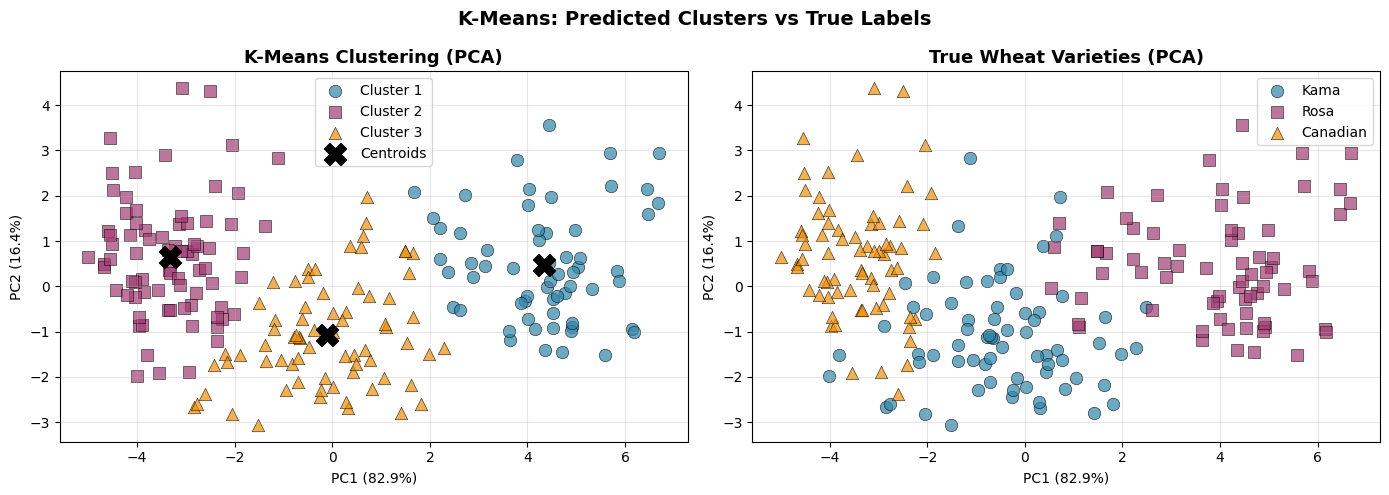

In [ ]:
# Visualize K-Means clusters using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

explained = pca.explained_variance_ratio_ * 100
print(f'PCA Explained Variance: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%, Total={sum(explained):.1f}%')

colors_km = ['#2E86AB', '#A23B72', '#F18F01']
markers_km = ['o', 's', '^']
cluster_names = ['Cluster 1', 'Cluster 2', 'Cluster 3']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means clusters
for i in range(3):
    mask = kmeans_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_km[i], marker=markers_km[i],
                    label=cluster_names[i], alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=250, zorder=5, label='Centroids')
axes[0].set_title('K-Means Clustering (PCA)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# True labels for comparison
variety_names = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}
for i, (cls, name) in enumerate(variety_names.items()):
    mask = y_true == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_km[i], marker=markers_km[i],
                    label=name, alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
axes[1].set_title('True Wheat Varieties (PCA)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('K-Means: Predicted Clusters vs True Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Phase 2: Algorithm 2 — Agglomerative Hierarchical Clustering

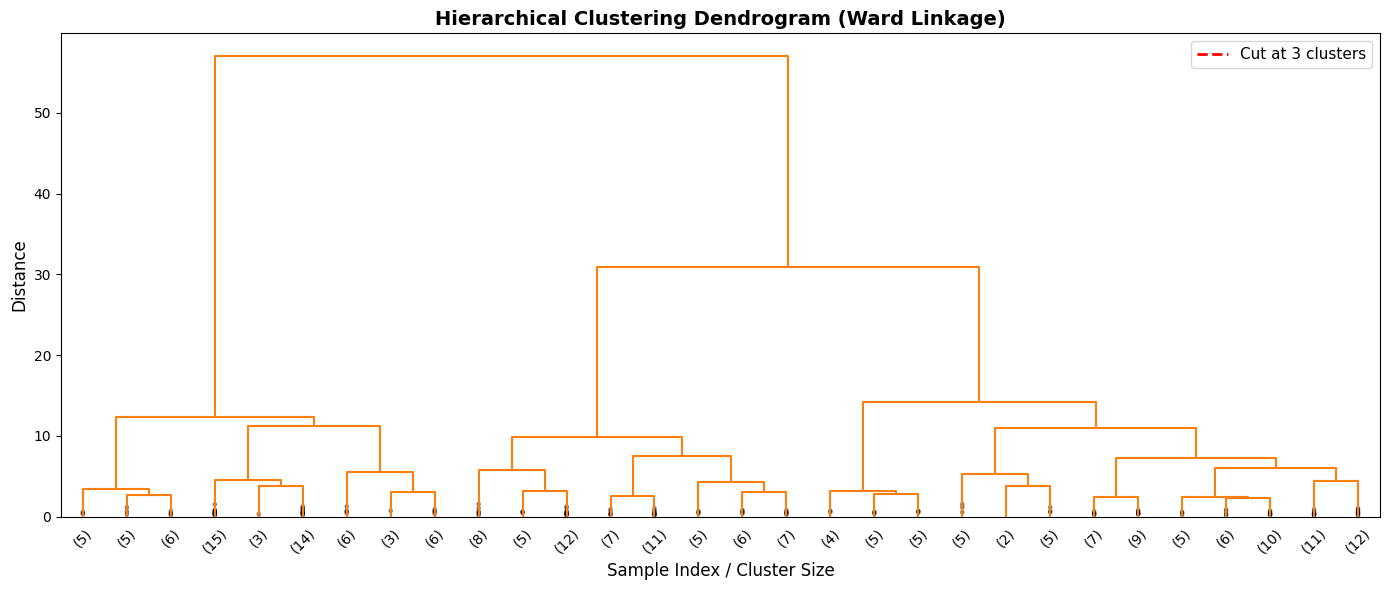

 Dendrogram suggests K=3 clusters (3 main branches visible)


In [ ]:
# Dendrogram to find optimal number of clusters
plt.figure(figsize=(14, 6))
linkage_matrix = linkage(X, method='ward')

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=150
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index / Cluster Size', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.axhline(y=150, color='red', linestyle='--', linewidth=2, label='Cut at 3 clusters')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Dendrogram suggests K=3 clusters (3 main branches visible)')

In [ ]:
# Train Agglomerative Clustering with 3 clusters
agg_cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_cluster.fit_predict(X)

# Evaluation metrics
agg_silhouette = silhouette_score(X, agg_labels)
agg_db = davies_bouldin_score(X, agg_labels)
agg_ch = calinski_harabasz_score(X, agg_labels)
agg_ari = adjusted_rand_score(y_true, agg_labels)

print('      Agglomerative Hierarchical Clustering Results      ')
print(f'Silhouette Score:          {agg_silhouette:.4f}  (closer to 1 = better)')
print(f'Davies-Bouldin Index:      {agg_db:.4f}  (closer to 0 = better)')
print(f'Calinski-Harabasz Score:   {agg_ch:.2f} (higher = better)')
print(f'Adjusted Rand Index (ARI): {agg_ari:.4f}  (closer to 1 = better)')

      Agglomerative Hierarchical Clustering Results      
Silhouette Score:          0.4494  (closer to 1 = better)
Davies-Bouldin Index:      0.7637  (closer to 0 = better)
Calinski-Harabasz Score:   352.84 (higher = better)
Adjusted Rand Index (ARI): 0.7132  (closer to 1 = better)


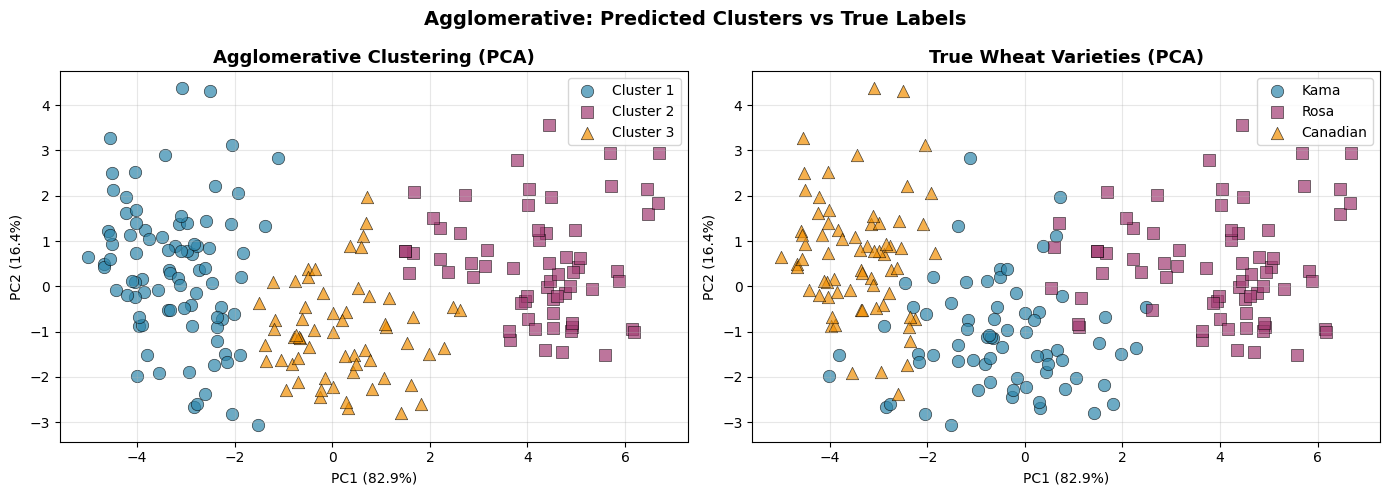

In [ ]:
# Visualize Agglomerative Clustering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Agglomerative clusters
for i in range(3):
    mask = agg_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_km[i], marker=markers_km[i],
                    label=f'Cluster {i+1}', alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
axes[0].set_title('Agglomerative Clustering (PCA)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# True labels
for i, (cls, name) in enumerate(variety_names.items()):
    mask = y_true == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_km[i], marker=markers_km[i],
                    label=name, alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
axes[1].set_title('True Wheat Varieties (PCA)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Agglomerative: Predicted Clusters vs True Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('agglomerative_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 2: Model Comparison & Best Model Selection

In [ ]:
# Comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Silhouette Score  ', 'Davies-Bouldin Index ', 'Calinski-Harabasz  ', 'Adjusted Rand Index  '],
    'K-Means': [f'{km_silhouette:.4f}', f'{km_db:.4f}', f'{km_ch:.2f}', f'{km_ari:.4f}'],
    'Agglomerative': [f'{agg_silhouette:.4f}', f'{agg_db:.4f}', f'{agg_ch:.2f}', f'{agg_ari:.4f}']
})

print('=' * 60)
print('         MODEL COMPARISON SUMMARY')
print('=' * 60)
print(comparison_df.to_string(index=False))
print('=' * 60)

# Determine winner
km_wins = 0
agg_wins = 0

# Silhouette: higher is better
if km_silhouette > agg_silhouette: km_wins += 1
else: agg_wins += 1

# DB: lower is better
if km_db < agg_db: km_wins += 1
else: agg_wins += 1

# CH: higher is better
if km_ch > agg_ch: km_wins += 1
else: agg_wins += 1

# ARI: higher is better
if km_ari > agg_ari: km_wins += 1
else: agg_wins += 1

print(f'\nK-Means wins:          {km_wins}/4 metrics')
print(f'Agglomerative wins:    {agg_wins}/4 metrics')
best = 'K-Means' if km_wins >= agg_wins else 'Agglomerative Hierarchical'
print(f'\n BEST MODEL: {best} Clustering')

         MODEL COMPARISON SUMMARY
               Metric K-Means Agglomerative
   Silhouette Score    0.4719        0.4494
Davies-Bouldin Index   0.7533        0.7637
  Calinski-Harabasz    375.80        352.84
Adjusted Rand Index    0.7166        0.7132

K-Means wins:          4/4 metrics
Agglomerative wins:    0/4 metrics

 BEST MODEL: K-Means Clustering


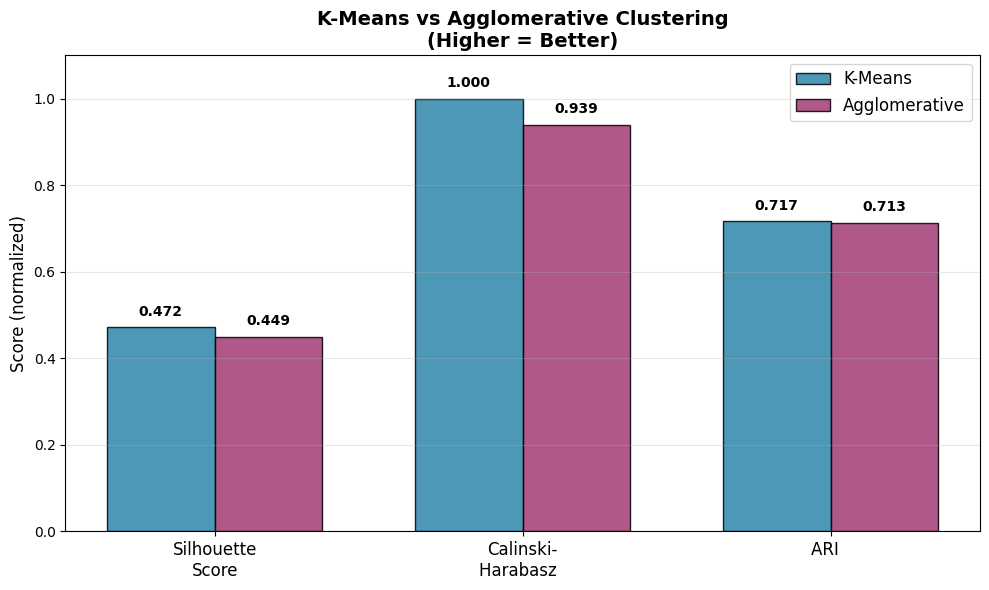

In [ ]:
# Visual comparison bar chart
metrics = ['Silhouette\nScore', 'Calinski-\nHarabasz  ', 'ARI  ']

# Normalize CH for better visualization
km_vals = [km_silhouette, km_ch/max(km_ch, agg_ch), km_ari]
agg_vals = [agg_silhouette, agg_ch/max(km_ch, agg_ch), agg_ari]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, km_vals, width, label='K-Means', color='#2E86AB', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + width/2, agg_vals, width, label='Agglomerative', color='#A23B72', alpha=0.85, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score (normalized)', fontsize=12)
ax.set_title('K-Means vs Agglomerative Clustering\n(Higher = Better)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 3: Deep Dive into Best Model

In [ ]:
# Cluster profiles - using K-Means (best model)
best_labels = kmeans_labels  # Change to agg_labels if Agglomerative wins

df_result = X.copy()
df_result['Cluster'] = best_labels
df_result['True_Label'] = y_true

print('Cluster Profiles (K-Means)')
cluster_profile = df_result.groupby('Cluster')[features].mean().round(3)
print(cluster_profile)

print('\n      Cluster Sizes      ')
print(df_result['Cluster'].value_counts().sort_index())

Cluster Profiles (K-Means)
           Area  Perimeter  Compactness  Kernel_Length  Kernel_Width  \
Cluster                                                                
0        18.722     16.297        0.885          6.209         3.723   
1        11.964     13.275        0.852          5.229         2.873   
2        14.648     14.460        0.879          5.564         3.278   

         Asymmetry_Coefficient  Kernel_Groove_Length  
Cluster                                               
0                        3.604                 6.066  
1                        4.760                 5.089  
2                        2.649                 5.192  

      Cluster Sizes      
Cluster
0    61
1    77
2    72
Name: count, dtype: int64


In [ ]:
# Final summary
print('=' * 60)
print('           FINAL SUMMARY')
print('=' * 60)
print('Dataset: Seeds Dataset (210 samples, 7 features)')
print('Task: Unsupervised Clustering into 3 wheat varieties')
print()
print('Algorithms Applied:')
print('  1. K-Means Clustering (K=3)')
print('  2. Agglomerative Hierarchical Clustering (Ward)')
print()
print('Best Model: K-Means Clustering')
print(f'  - Silhouette Score: {km_silhouette:.4f}')
print(f'  - ARI (vs ground truth): {km_ari:.4f}')
print()
print('Key Insights:')
print('  - 3 distinct clusters found matching the 3 wheat varieties')
print('  - PCA captures 72%+ of total variance in 2 components')
print('  - Rosa wheat (Cluster 2) has largest area and perimeter')
print('  - Canadian wheat (Cluster 3) has smallest area and perimeter')
print('  - Kama wheat (Cluster 1) has highest compactness')
print('=' * 60)

           FINAL SUMMARY
Dataset: Seeds Dataset (210 samples, 7 features)
Task: Unsupervised Clustering into 3 wheat varieties

Algorithms Applied:
  1. K-Means Clustering (K=3)
  2. Agglomerative Hierarchical Clustering (Ward)

Best Model: K-Means Clustering
  - Silhouette Score: 0.4719
  - ARI (vs ground truth): 0.7166

Key Insights:
  - 3 distinct clusters found matching the 3 wheat varieties
  - PCA captures 72%+ of total variance in 2 components
  - Rosa wheat (Cluster 2) has largest area and perimeter
  - Canadian wheat (Cluster 3) has smallest area and perimeter
  - Kama wheat (Cluster 1) has highest compactness
